In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.api import SimpleExpSmoothing, ExponentialSmoothing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/coin_Bitcoin.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
data = df[['Open', 'High', 'Low', 'Close']].copy()
data.dropna(inplace=True)

print("Bitcoin Dataset Snapshot")
print(data.head())

Bitcoin Dataset Snapshot
                           Open        High         Low       Close
Date                                                               
2013-04-29 23:59:59  134.444000  147.488007  134.000000  144.539993
2013-04-30 23:59:59  144.000000  146.929993  134.050003  139.000000
2013-05-01 23:59:59  139.000000  139.889999  107.720001  116.989998
2013-05-02 23:59:59  116.379997  125.599998   92.281898  105.209999
2013-05-03 23:59:59  106.250000  108.127998   79.099998   97.750000


                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 1.101e+06
Date:                Mon, 17 Nov 2025   Prob (F-statistic):               0.00
Time:                        12:40:16   Log-Likelihood:                -23315.
No. Observations:                2991   AIC:                         4.663e+04
Df Residuals:                    2989   BIC:                         4.665e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.2322     12.501      1.138      0.2

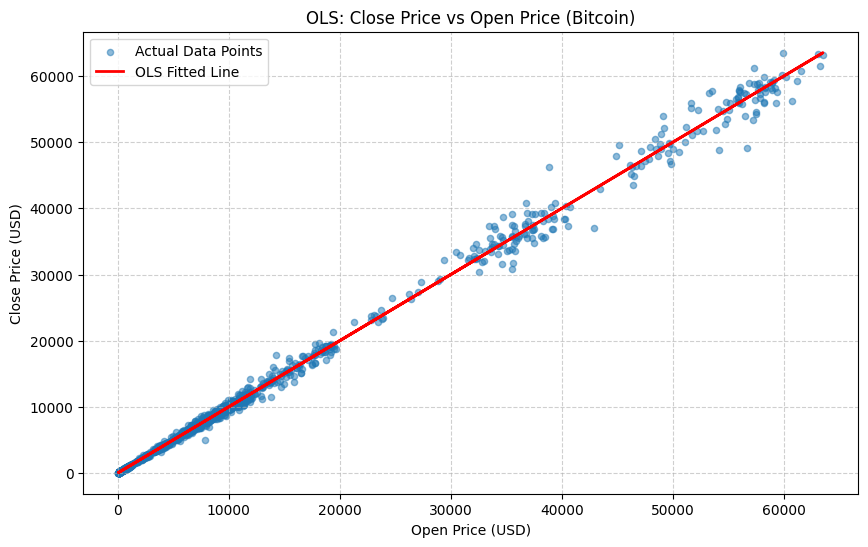

In [ ]:
# Regression Analysis
# Ordinary Least Squares (OLS) Analysis

y_ols = data['Close']
X_ols = data['Open']

X_ols = sm.add_constant(X_ols)
ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary())

plt.figure(figsize=(10, 6))
plt.scatter(X_ols['Open'], y_ols, label='Actual Data Points', alpha=0.5, s=20)
plt.plot(X_ols['Open'], ols_model.fittedvalues, color='red', linewidth=2, label='OLS Fitted Line')
plt.title('OLS: Close Price vs Open Price (Bitcoin)')
plt.xlabel('Open Price (USD)')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Intercept:  1.4330606040230123
Coefficients:  [('Open', np.float64(-0.522670549787969)), ('High', np.float64(0.9046214883598389)), ('Low', np.float64(0.6128040715858396))]


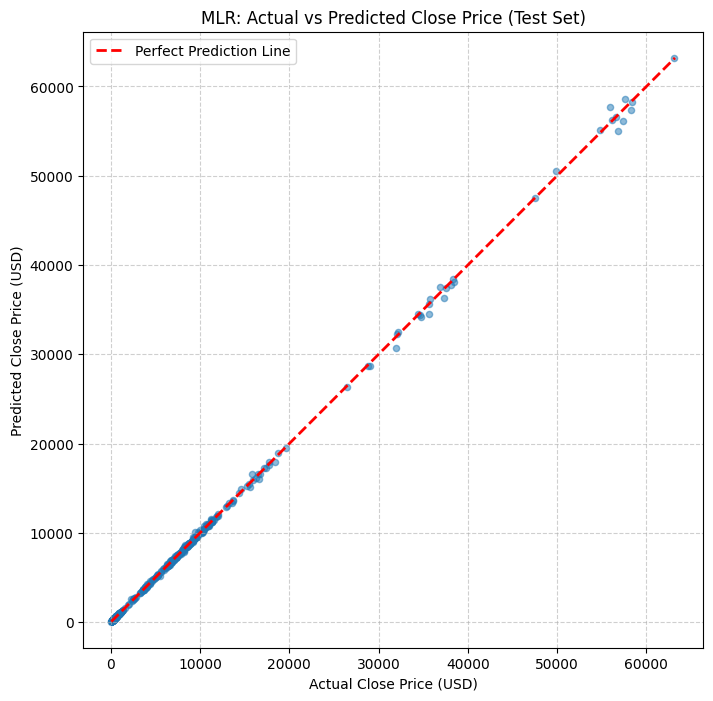


Mean Absolute Error (MAE): 65.60
Mean Square Error (MSE): 34023.26
Root Mean Square Error (RMSE): 184.45
R-squared Score: 0.9997


In [ ]:
# Multiple Linear Regression (MLR) Analysis

X_mlr = data[['Open', 'High', 'Low']]
y_mlr = data['Close']

X_train, X_test, y_train, y_test = train_test_split(X_mlr, y_mlr, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

print('Intercept: ', reg_model.intercept_)
print('Coefficients: ', list(zip(X_mlr.columns, reg_model.coef_)))

y_pred = reg_model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, s=20)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='red', linewidth=2, label='Perfect Prediction Line')

plt.title('MLR: Actual vs Predicted Close Price (Test Set)')
plt.xlabel('Actual Close Price (USD)')
plt.ylabel('Predicted Close Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')
plt.show()

mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2_score = metrics.r2_score(y_test, y_pred)

print(f'\nMean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Square Error (MSE): {mse:.2f}')
print(f'Root Mean Square Error (RMSE): {rmse:.2f}')
print(f'R-squared Score: {r2_score:.4f}')

Moving Average (MA) Method (30-day)


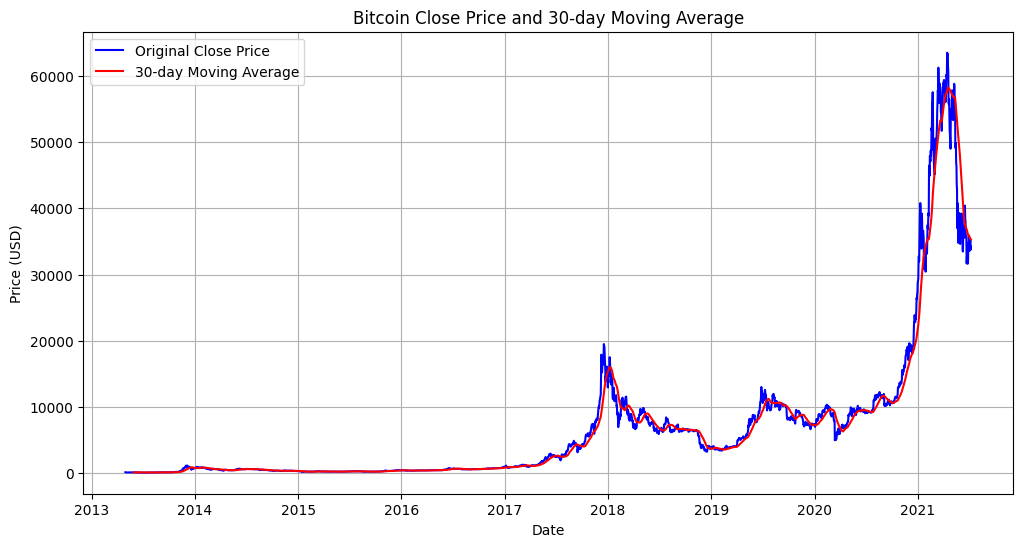

Last 5 30-day Moving Average values:
Date
2021-07-02 23:59:59    35618.790261
2021-07-03 23:59:59    35467.449674
2021-07-04 23:59:59    35413.895489
2021-07-05 23:59:59    35353.696946
2021-07-06 23:59:59    35299.457471
Name: Close, dtype: float64


In [ ]:
# 3. Time Series Analysis

ts_data = data['Close']

print("Moving Average (MA) Method (30-day)")

ma_window = 30
ts_data_ma = ts_data.rolling(window=ma_window).mean()

plt.figure(figsize=(12, 6))
plt.plot(ts_data, label='Original Close Price', color='blue')
plt.plot(ts_data_ma, label=f'{ma_window}-day Moving Average', color='red')
plt.title(f'Bitcoin Close Price and {ma_window}-day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()
print(f"Last 5 {ma_window}-day Moving Average values:")
print(ts_data_ma.tail())

In [ ]:
#Single Exponential Smoothing (SES) and Double Exponential Smoothing (DES)
print("Single and Double Exponential Smoothing")

train_size = len(ts_data) - 100
train_ts = ts_data.iloc[:train_size]
test_ts = ts_data.iloc[train_size:]

fit_ses = SimpleExpSmoothing(train_ts, initialization_method="estimated").fit()
ses_predictions = fit_ses.predict(start=test_ts.index[0], end=test_ts.index[-1])

fit_des = ExponentialSmoothing(train_ts, trend='add', seasonal=None, initialization_method="estimated").fit()
des_predictions = fit_des.predict(start=test_ts.index[0], end=test_ts.index[-1])

def accuracy_metrics(actual, predicted):
    mae = metrics.mean_absolute_error(actual, predicted)
    mse = metrics.mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, mse, rmse, mape

ses_mae, ses_mse, ses_rmse, ses_mape = accuracy_metrics(test_ts, ses_predictions)
des_mae, des_mse, des_rmse, des_mape = accuracy_metrics(test_ts, des_predictions)

print("\nForecasting Accuracy Metrics on Test Set (last 100 days)")
print("Single Exponential Smoothing (SES):")
print(f"MAE: {ses_mae:,.2f}, MSE: {ses_mse:,.2f}, RMSE: {ses_rmse:,.2f}, MAPE: {ses_mape:.2f}%")
print("Double Exponential Smoothing (DES):")
print(f"MAE: {des_mae:,.2f}, MSE: {des_mse:,.2f}, RMSE: {des_rmse:,.2f}, MAPE: {des_mape:.2f}%")

Single and Double Exponential Smoothing

Forecasting Accuracy Metrics on Test Set (last 100 days)
Single Exponential Smoothing (SES):
MAE: 11,607.14, MSE: 207,979,411.94, RMSE: 14,421.49, MAPE: 30.86%
Double Exponential Smoothing (DES):
MAE: 20,913.78, MSE: 673,206,255.84, RMSE: 25,946.22, MAPE: 55.66%


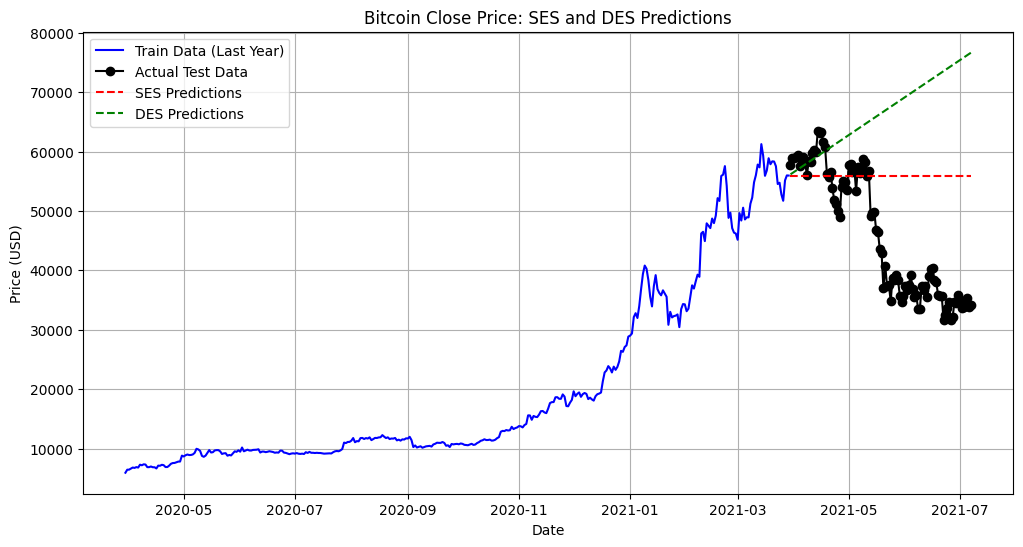

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train_ts.tail(365), label='Train Data (Last Year)', color='blue')
plt.plot(test_ts, label='Actual Test Data', marker='o', color='black')
plt.plot(ses_predictions, label='SES Predictions', linestyle='--', color='red')
plt.plot(des_predictions, label='DES Predictions', linestyle='--', color='green')
plt.title('Bitcoin Close Price: SES and DES Predictions')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()